# Lab 03: Linear & Affine Transformations

| Task | Scenario | Transformation |
|---|---|---|
| 1 | The Tiny Fingerprint | Scale (2×2), 300%, keep centered |
| 2 | The Dizzy Satellite | Rotation (2×2), 45°, expand canvas |
| 3 | The Fast Train Barcode | Shear (2×2), de-slant |
| 4 | The Hidden Treasure Map | Translation (3×3 affine), 150 px / 80 px |

All matrices are built by hand with NumPy, and a manual inverse-mapping warp (with bilinear interpolation) applies them. Each result is cross-checked against `cv2.warpAffine`.

## 0. Setup & Configuration

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------ PLACEHOLDERS: EDIT THESE ------------------
FINGERPRINT_PATH = "Thukuna.jpg"   # Task 1
SATELLITE_PATH   = "Thukuna.jpg"     # Task 2
BARCODE_PATH     = "Thukuna.jpg"       # Task 3
TREASURE_MAP_PATH = "Thukuna.jpg" # Task 4
OUTPUT_DIR       = "output"     # where results are saved
SAVE_OUTPUTS     = False
# --------------------------------------------------------------

# Task parameters
if os.path.exists(OUTPUT_DIR) and SAVE_OUTPUTS:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
SCALE_X, SCALE_Y = 3.0, 3.0        # Task 1: 300%
SCREEN_W, SCREEN_H = None, None    # Task 1: screen size in px; None -> 4x the image size
TILT_ANGLE_DEG = 45                # Task 2: angle the satellite was rotated by
SHEAR_K = 0.3                      # Task 3: horizontal shear factor (x' = x + k*y)
MAP_SHIFT_X, MAP_SHIFT_Y = 150, 80 # Task 4: map is 150 px left and 80 px up -> shift right/down

if SAVE_OUTPUTS:
    import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img

def save(name, img):
    if SAVE_OUTPUTS:
        cv2.imwrite(os.path.join(OUTPUT_DIR, name), img)

def show(images, titles, figsize=(14, 6)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for a, im, t in zip(axes, images, titles):
        a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        a.set_title(f"{t}  ({im.shape[1]}x{im.shape[0]})")
        a.axis("on")
    plt.tight_layout(); plt.show()

## 1. Shared Tools

**Homogeneous embedding.** A 2×2 matrix $A$ and translation $t$ combine into one 3×3 matrix:

$$M = \begin{bmatrix} a_{11} & a_{12} & t_x \\ a_{21} & a_{22} & t_y \\ 0 & 0 & 1 \end{bmatrix}$$

**Keeping the content centered.** Any linear map $A$ acts about the origin (the top-left pixel). To transform about the image center $c_{in}$ and land at the output center $c_{out}$:

$$p' = A\,(p - c_{in}) + c_{out} = A\,p + \underbrace{(c_{out} - A\,c_{in})}_{t}$$

**Manual warp (inverse mapping).** For every output pixel we compute $p_{src} = M^{-1} p_{out}$ and sample the source with bilinear interpolation. This avoids holes that forward mapping leaves.

In [3]:
def to_homogeneous(A, t=(0.0, 0.0)):
    """Embed a 2x2 matrix A and translation t into a 3x3 affine matrix."""
    M = np.eye(3, dtype=np.float64)
    M[:2, :2] = A
    M[:2, 2] = t
    return M

def centered_translation(A, c_in, c_out):
    """t = c_out - A @ c_in, so the transform pivots on the image center."""
    return np.asarray(c_out, dtype=np.float64) - A @ np.asarray(c_in, dtype=np.float64)

def image_center(w, h):
    return np.array([(w - 1) / 2.0, (h - 1) / 2.0])

def warp_manual(img, M, out_w, out_h):
    """Warp img by 3x3 matrix M (source -> output) using inverse mapping + bilinear interpolation."""
    h, w = img.shape[:2]
    Minv = np.linalg.inv(M)

    xs, ys = np.meshgrid(np.arange(out_w), np.arange(out_h))
    coords = np.stack([xs.ravel(), ys.ravel(), np.ones(xs.size)])      # 3 x N
    src = Minv @ coords
    sx = src[0].reshape(out_h, out_w)
    sy = src[1].reshape(out_h, out_w)

    valid = (sx >= 0) & (sx <= w - 1) & (sy >= 0) & (sy <= h - 1)
    x0 = np.clip(np.floor(sx).astype(int), 0, w - 1)
    y0 = np.clip(np.floor(sy).astype(int), 0, h - 1)
    x1 = np.clip(x0 + 1, 0, w - 1)
    y1 = np.clip(y0 + 1, 0, h - 1)
    wx = sx - np.floor(sx)
    wy = sy - np.floor(sy)
    if img.ndim == 3:
        wx, wy, valid = wx[..., None], wy[..., None], valid[..., None]

    f = img.astype(np.float64)
    out = (f[y0, x0] * (1 - wx) * (1 - wy) + f[y0, x1] * wx * (1 - wy) +
           f[y1, x0] * (1 - wx) * wy       + f[y1, x1] * wx * wy)
    out = np.where(valid, out, 0)
    return np.clip(np.rint(out), 0, 255).astype(np.uint8)

def cv2_check(img, M, out_w, out_h, manual_result):
    """Cross-check against OpenCV (small differences at borders are normal)."""
    ref = cv2.warpAffine(img, M[:2], (out_w, out_h), flags=cv2.INTER_LINEAR)
    diff = np.abs(ref.astype(int) - manual_result.astype(int))
    print(f"Mean abs difference vs cv2.warpAffine: {diff.mean():.3f}")
    return ref

## Task 1: The Tiny Fingerprint (Scale)

**Scaling matrix**

$$S = \begin{bmatrix} s_x & 0 \\ 0 & s_y \end{bmatrix} = \begin{bmatrix} 3 & 0 \\ 0 & 3 \end{bmatrix}$$

**Centering on screen.** Scaling about the origin pushes the fingerprint toward the bottom-right. Its center moves from $c_{in}$ to $S\,c_{in}$, so we translate by

$$t = c_{screen} - S\,c_{in}$$

which puts the enlarged fingerprint's center on the screen's center.

Scaling matrix S:
 [[3. 0.]
 [0. 3.]]
Image center: [167. 298.] | Screen center: [ 669.5 1193.5]
Translation t = c_screen - S @ c_in = [168.5 299.5]
3x3 matrix:
 [[  3.    0.  168.5]
 [  0.    3.  299.5]
 [  0.    0.    1. ]]
Mean abs difference vs cv2.warpAffine: 0.268
Content bbox center: (669.5, 1186.5) | Screen center: (669.5, 1193.5)


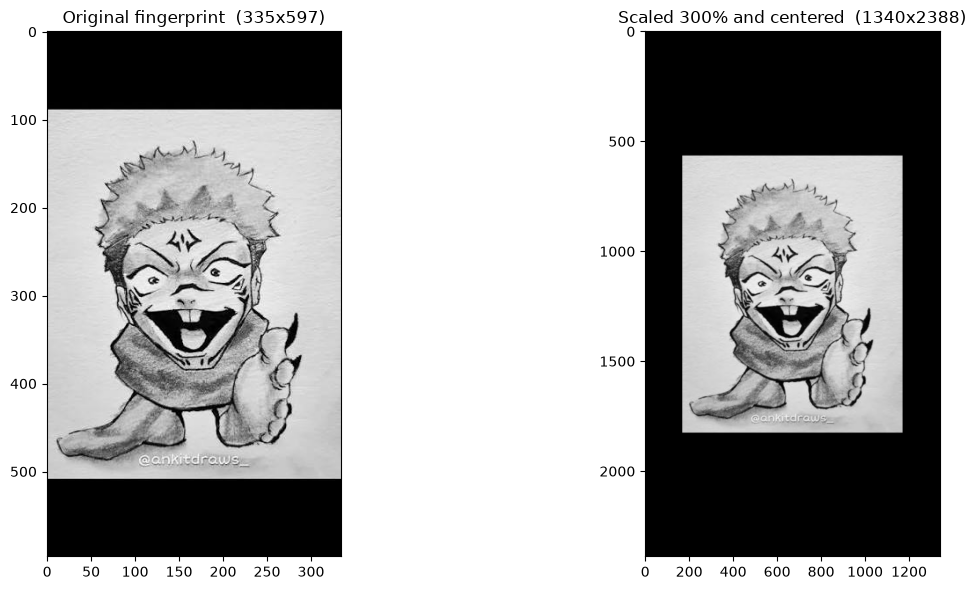

In [4]:
fp = load_image(FINGERPRINT_PATH)
h, w = fp.shape[:2]

# 2x2 scaling matrix, built manually
S = np.array([[SCALE_X, 0.0],
              [0.0, SCALE_Y]])

# Screen (output canvas) size
screen_w = SCREEN_W or int(round(4 * w))
screen_h = SCREEN_H or int(round(4 * h))

c_in = image_center(w, h)
c_screen = image_center(screen_w, screen_h)
t = centered_translation(S, c_in, c_screen)
M1 = to_homogeneous(S, t)

print("Scaling matrix S:\n", S)
print("Image center:", c_in, "| Screen center:", c_screen)
print("Translation t = c_screen - S @ c_in =", t)
print("3x3 matrix:\n", np.round(M1, 3))

fp_big = warp_manual(fp, M1, screen_w, screen_h)
_ = cv2_check(fp, M1, screen_w, screen_h, fp_big)

# Verify centering: the center of the non-black region should sit at the screen center
ys, xs = np.nonzero(fp_big.sum(axis=2) > 0)
print(f"Content bbox center: ({(xs.min()+xs.max())/2:.1f}, {(ys.min()+ys.max())/2:.1f})"
      f" | Screen center: ({c_screen[0]:.1f}, {c_screen[1]:.1f})")

show([fp, fp_big], ["Original fingerprint", f"Scaled {SCALE_X*100:.0f}% and centered"])
save("task1_fingerprint_scaled.png", fp_big)

## Task 2: The Dizzy Satellite (Rotation)

**Rotation matrix**

$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

To undo a 45° tilt we apply $R(-45^\circ)$.

> Image coordinates have $y$ pointing **down**, so a positive $\theta$ looks clockwise on screen. If the result spins the wrong way, flip the sign of `CORRECTION_ANGLE`.

**New canvas size.** A rotated $W \times H$ rectangle has a bounding box of

$$W' = |W\cos\theta| + |H\sin\theta|, \qquad H' = |W\sin\theta| + |H\cos\theta|$$

We confirm this by rotating the four corners manually. We then rotate about the image center and re-center on the new canvas, so no corner is chopped.

Original size: 335x597 | Correction angle: -45 deg
Rotation matrix R:
 [[ 0.7071  0.7071]
 [-0.7071  0.7071]]
New canvas (formula): 660x660 | Corner check: 658.6x658.6
Mean abs difference vs cv2.warpAffine: 0.055


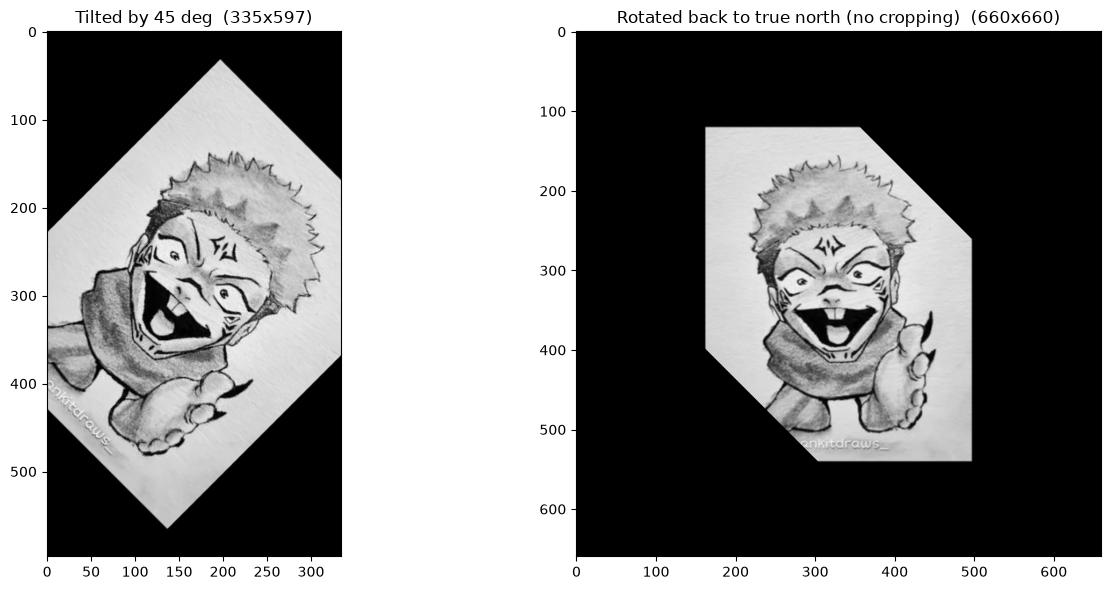

In [12]:
satel = load_image(SATELLITE_PATH)

# Artificially tilting 45 degrees Thukuna for demonstration purposes
(r, c) = satel.shape[:2]
center = (c // 2, r // 2)
rotation_mat = cv2.getRotationMatrix2D(center, -45, 1.0)
sat = cv2.warpAffine(satel, rotation_mat, (c, r), flags=cv2.INTER_LINEAR)

h, w = sat.shape[:2]

CORRECTION_ANGLE = -TILT_ANGLE_DEG        # flip sign if it spins the wrong way
theta = np.deg2rad(CORRECTION_ANGLE)
cos_t, sin_t = np.cos(theta), np.sin(theta)

# 2x2 rotation matrix from sine and cosine
R = np.array([[cos_t, -sin_t],
              [sin_t,  cos_t]])

# New dimensions (formula)
new_w = int(np.ceil(abs(w * cos_t) + abs(h * sin_t)))
new_h = int(np.ceil(abs(w * sin_t) + abs(h * cos_t)))

# Verify by rotating the corners about the image center
c_in = image_center(w, h)
corners = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype=float)
rot_corners = (corners - c_in) @ R.T
span_w = rot_corners[:, 0].max() - rot_corners[:, 0].min() + 1
span_h = rot_corners[:, 1].max() - rot_corners[:, 1].min() + 1

c_out = image_center(new_w, new_h)
t = centered_translation(R, c_in, c_out)
M2 = to_homogeneous(R, t)

print(f"Original size: {w}x{h} | Correction angle: {CORRECTION_ANGLE} deg")
print("Rotation matrix R:\n", np.round(R, 4))
print(f"New canvas (formula): {new_w}x{new_h} | Corner check: {span_w:.1f}x{span_h:.1f}")

sat_fixed = warp_manual(sat, M2, new_w, new_h)
_ = cv2_check(sat, M2, new_w, new_h, sat_fixed)

show([sat, sat_fixed], [f"Tilted by {TILT_ANGLE_DEG} deg", "Rotated back to true north (no cropping)"])
save("task2_satellite_rotated.png", sat_fixed)

## Task 3: The Fast Train Barcode (Shear)

**Horizontal shear matrix**

$$H_k = \begin{bmatrix} 1 & k \\ 0 & 1 \end{bmatrix} \quad\Rightarrow\quad x' = x + k\,y,\quad y' = y$$

Each row is pushed sideways in proportion to its height $y$. Choosing $k$ opposite to the slant straightens the bars:

$$k = \tan(\text{slant angle from vertical})$$

You can measure the slant by picking two points on one bar edge: $k = \Delta x / \Delta y$ (sign flipped as needed).

> If the bars lean the *other* way after correction, flip the sign of `SHEAR_K`.

**Canvas width.** Shearing moves the bottom row by $k\cdot H$ pixels, so we widen the canvas to $W + |k|\,H$ (and translate by $-kH$ when $k<0$) so nothing is clipped. The fully valid rectangle is then cropped out.

Shear matrix:
 [[1.  0.3]
 [0.  1. ]]
Original: 335x597 -> sheared canvas: 515x597
Mean abs difference vs cv2.warpAffine: 0.265
Cropped rectangle size: 156 x 597


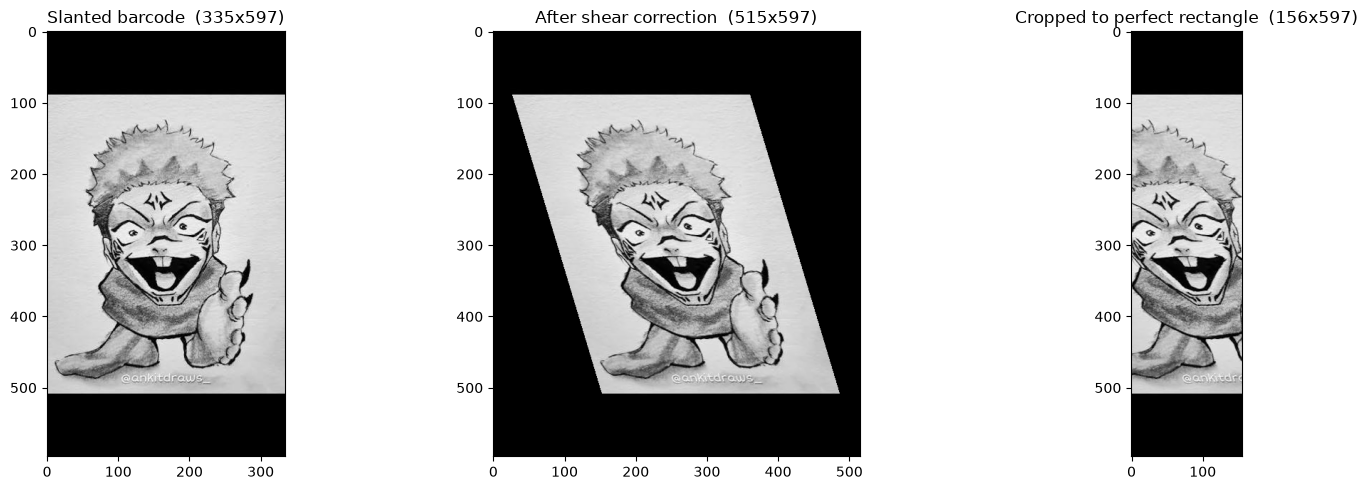

In [6]:
bar = load_image(BARCODE_PATH)
h, w = bar.shape[:2]

# 2x2 shear matrix, built manually
Hk = np.array([[1.0, SHEAR_K],
               [0.0, 1.0]])

# Canvas big enough to hold the sheared image
out_w = int(np.ceil(w + abs(SHEAR_K) * h))
out_h = h
tx = -SHEAR_K * (h - 1) if SHEAR_K < 0 else 0.0     # keep all pixels in view
M3 = to_homogeneous(Hk, (tx, 0.0))

print("Shear matrix:\n", Hk)
print(f"Original: {w}x{h} -> sheared canvas: {out_w}x{out_h}")

bar_sheared = warp_manual(bar, M3, out_w, out_h)
_ = cv2_check(bar, M3, out_w, out_h, bar_sheared)

# Crop to the perfect rectangle: columns that are covered by image data on every row
shift = abs(SHEAR_K) * (h - 1)
left = int(np.ceil(shift))
right = w - 1                                      # valid columns on every row: [|k|*(h-1), w-1]
bar_rect = bar_sheared[:, left:right + 1]
print("Cropped rectangle size:", bar_rect.shape[1], "x", bar_rect.shape[0])

show([bar, bar_sheared, bar_rect],
     ["Slanted barcode", "After shear correction", "Cropped to perfect rectangle"], figsize=(16, 5))
save("task3_barcode_corrected.png", bar_rect)

## Task 4: The Hidden Treasure Map (Affine Translation)

A pure translation cannot be written as a 2×2 matrix, because it is not linear (it moves the origin). Moving to **homogeneous coordinates** fixes this:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

The "X" sits 150 px **left** and 80 px **up** of the visible frame, so we slide the map **right 150** and **down 80**: $t_x = +150,\ t_y = +80$.

The canvas is made larger by $(t_x, t_y)$ so no part of the map is cut off. A same-size-frame version is shown as well.

Translation matrix:
 [[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]
Mean abs difference vs cv2.warpAffine: 0.000
Pixel (100,60) -> (250,140): True


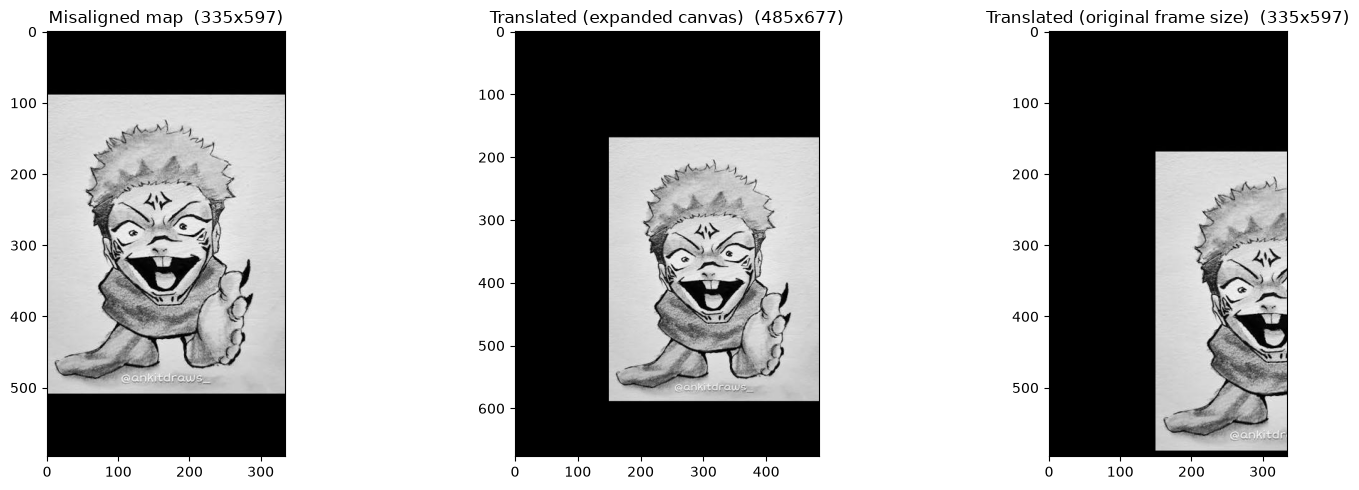

In [7]:
tmap = load_image(TREASURE_MAP_PATH)
h, w = tmap.shape[:2]

# 3x3 translation matrix, built manually
M4 = np.array([[1.0, 0.0, MAP_SHIFT_X],
               [0.0, 1.0, MAP_SHIFT_Y],
               [0.0, 0.0, 1.0]])
print("Translation matrix:\n", M4)

# (a) Expanded canvas: nothing is lost
exp_w, exp_h = w + abs(MAP_SHIFT_X), h + abs(MAP_SHIFT_Y)
map_expanded = warp_manual(tmap, M4, exp_w, exp_h)
_ = cv2_check(tmap, M4, exp_w, exp_h, map_expanded)

# (b) Same-size frame: shifted content now fills the view
map_same = warp_manual(tmap, M4, w, h)

# Sanity check: a pixel at (x, y) lands at (x + tx, y + ty)
px, py = 100, 60
print(f"Pixel ({px},{py}) -> ({px + MAP_SHIFT_X},{py + MAP_SHIFT_Y}):",
      np.array_equal(tmap[py, px], map_expanded[py + MAP_SHIFT_Y, px + MAP_SHIFT_X]))

show([tmap, map_expanded, map_same],
     ["Misaligned map", "Translated (expanded canvas)", "Translated (original frame size)"], figsize=(16, 5))
save("task4_map_translated.png", map_expanded)

## Summary

| Task | Matrix | Key idea |
|---|---|---|
| 1. Scale | $\begin{bmatrix}3&0\\0&3\end{bmatrix}$ | $t = c_{screen} - S\,c_{in}$ keeps the content centered |
| 2. Rotation | $\begin{bmatrix}\cos\theta&-\sin\theta\\ \sin\theta&\cos\theta\end{bmatrix}$ | $W'=\lvert W\cos\theta\rvert+\lvert H\sin\theta\rvert$ (and the same for $H'$) prevents cropping |
| 3. Shear | $\begin{bmatrix}1&k\\0&1\end{bmatrix}$ | Pushes rows horizontally in proportion to $y$; widen the canvas by $\lvert k\rvert H$ |
| 4. Translation | $\begin{bmatrix}1&0&t_x\\0&1&t_y\\0&0&1\end{bmatrix}$ | The 3×3 homogeneous form lets translation be a matrix product |